In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2,random_state=23)

In [3]:
X.shape

(1000, 2)

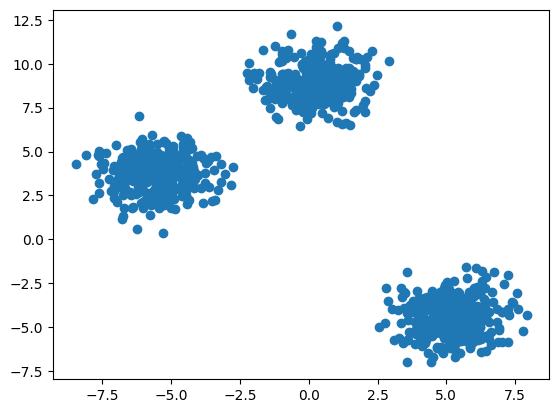

In [4]:
plt.scatter(X[:,0],X[:,1])

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [6]:
from sklearn.cluster import KMeans

In [8]:
## Manual Process
## Elbow Method to select the K value

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,init="k-means++")
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [9]:
wcss

[34827.57682552022,
 7935.437286145416,
 1319.2730531585607,
 1140.467788465513,
 992.0708509383511,
 854.6338301205803,
 765.617386680159,
 689.3894462922049,
 593.7456433516418,
 548.8379927019676]

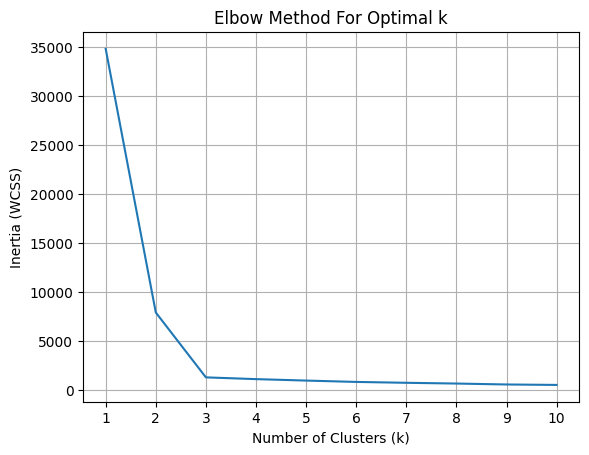

In [10]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [13]:
y_labels=kmeans.fit_predict(X_train)

In [14]:
y_test_label = kmeans.predict(X_test)

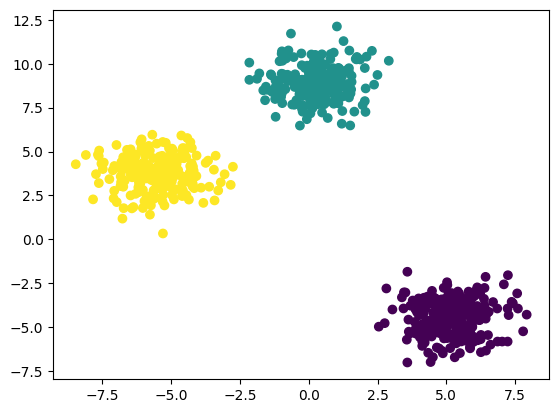

In [15]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

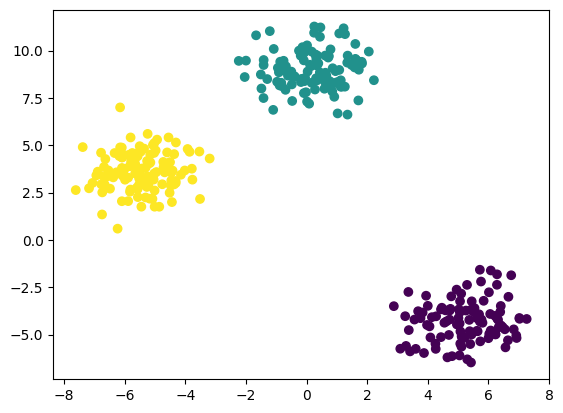

In [17]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)

In [18]:
#knee locator
!pip install kneed

In [27]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11),wcss,curve='convex',direction = 'decreasing')
print(kl.elbow)

3


In [29]:
## Performance metrics
## Silhoutte score
from sklearn.metrics import silhouette_score

In [31]:
silhouette_coeff = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coeff.append(score)
silhouette_coeff

[0.33245612847711964,
 0.3390487276626262,
 0.33803720960892186,
 0.3135277999528791,
 0.3244390909302882,
 0.34253693964741355,
 0.33230009808807004,
 0.3387662732550863,
 0.32962204762598174]

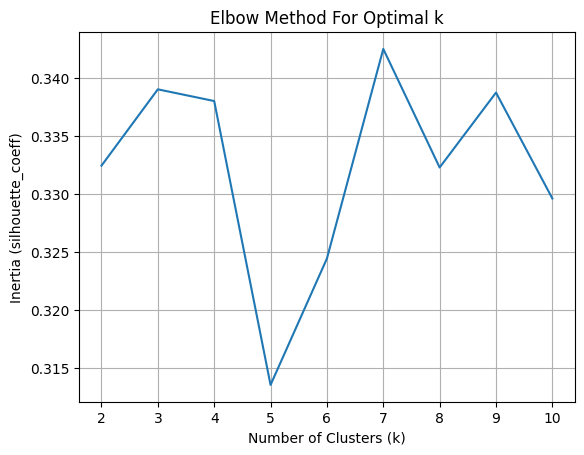

In [33]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (silhouette_coeff)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()